<a href="https://colab.research.google.com/github/Petra-Tembei/breast-cancer-classification/blob/main/breast_cancer_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Tumor Classification
## Can Cell Morphology Tell Us What a Pathologist Already Knows?

**Author:** *Petra Tembei*  
**Dataset:** Wisconsin Breast Cancer Diagnostic Dataset (UCI Machine Learning Repository / `sklearn`)  
**Models:** Logistic Regression · Support Vector Machine (RBF kernel)  
**Language:** Python 3  

---

### Project Summary

Fine needle aspiration (FNA) is a minimally invasive biopsy technique. When a suspicious breast
mass is sampled, a cytologist measures characteristics of the cell nuclei in the digital image;
things like radius, texture, concavity, and symmetry.

This project asks a simple but consequential question: **can a machine learning model learn to
distinguish malignant from benign tumors using only these geometric measurements?**

If so, it could serve as a decision-support tool, flagging high-risk cases for expedited
pathologist review, or providing a second opinion in resource-limited settings.

I evaluate two classification models: **Logistic Regression** (for interpretability and clinical
transparency) and a **Support Vector Machine with RBF kernel** (for discriminative power). Both are
assessed via AUC-ROC, precision-recall, and confusion matrix analysis.


## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

import warnings
warnings.filterwarnings("ignore")

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

print("All libraries loaded ✓")


All libraries loaded ✓


## 2. Data Loading & Overview

The Wisconsin Breast Cancer Diagnostic dataset contains **569 samples** and **30 numeric features**
computed from digitised FNA images. Each feature is calculated three ways including mean, standard error,
and "worst" (largest) value across the nuclei in the image.

The target variable is binary: **Malignant (0)** or **Benign (1)**.


In [2]:
# Load dataset
data = load_breast_cancer()
df   = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target  # 0 = Malignant, 1 = Benign

print(f"Dataset shape : {df.shape}")
print(f"Malignant     : {(df.target == 0).sum()} samples ({(df.target == 0).mean():.1%})")
print(f"Benign        : {(df.target == 1).sum()} samples ({(df.target == 1).mean():.1%})")
print()
df.describe().T[["mean","std","min","max"]].round(3).head(10)


Dataset shape : (569, 31)
Malignant     : 212 samples (37.3%)
Benign        : 357 samples (62.7%)



,mean,std,min,max
mean radius,14.127,3.524,6.981,28.110
mean texture,19.290,4.301,9.710,39.280
mean perimeter,91.969,24.299,43.790,188.500
mean area,654.889,351.914,143.500,2501.000
mean smoothness,0.096,0.014,0.053,0.163
mean compactness,0.104,0.053,0.019,0.345
mean concavity,0.089,0.080,0.000,0.427
mean concave points,0.049,0.039,0.000,0.201
mean symmetry,0.181,0.027,0.106,0.304
mean fractal dimension,0.063,0.007,0.050,0.097


## 3. Exploratory Data Analysis

### 3.1 Class Distribution


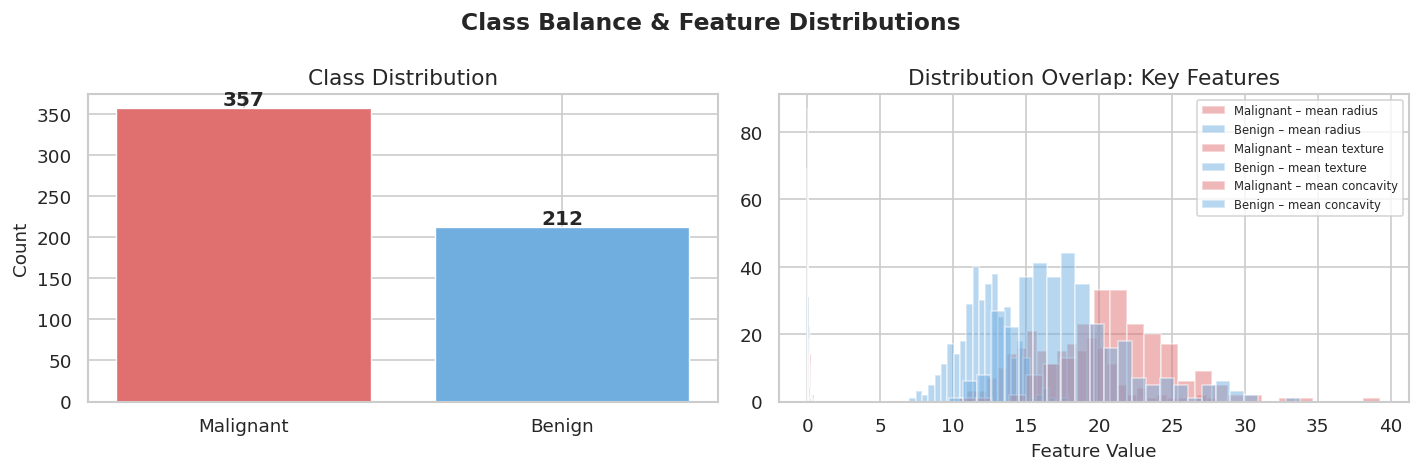

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = df["target"].value_counts()
axes[0].bar(["Malignant", "Benign"], counts.values,
            color=["#e07070", "#70aee0"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 4, str(v), ha="center", fontweight="bold")

# Three key features by class
key_features = ["mean radius", "mean texture", "mean concavity"]
colors = {0: "#e07070", 1: "#70aee0"}
for feature in key_features:
    for label, grp in df.groupby("target"):
        axes[1].hist(grp[feature], alpha=0.5, bins=25,
                     label=f"{'Benign' if label else 'Malignant'} – {feature}",
                     color=colors[label])

axes[1].set_title("Distribution Overlap: Key Features")
axes[1].set_xlabel("Feature Value")
axes[1].legend(fontsize=7)

plt.suptitle("Class Balance & Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_distributions.png", bbox_inches="tight")
plt.show()


### 3.2 Correlation Heatmap (Mean Features)

High inter-feature correlation is expected e.i. radius, perimeter, and area are all geometric
measures of the same thing. This is important to keep in mind when interpreting Logistic
Regression coefficients, but does not meaningfully harm SVM's discriminative performance.


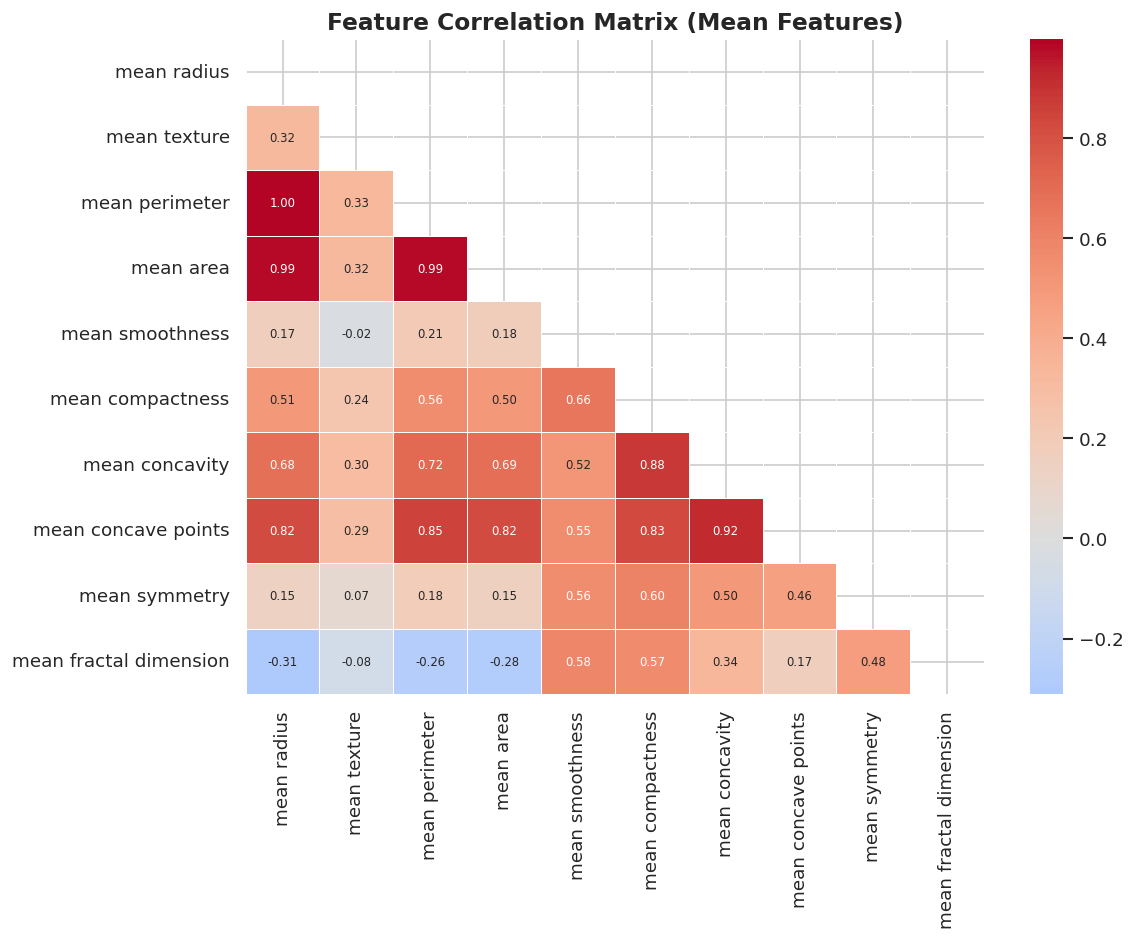

In [4]:
# Correlation heatmap — mean features only
mean_cols = [c for c in df.columns if c.startswith("mean")]
corr = df[mean_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title("Feature Correlation Matrix (Mean Features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlation.png", bbox_inches="tight")
plt.show()


### 3.3 Feature Separation by Class

Boxplots for the top diagnostic features reveal strong class separation, malignant tumors
consistently show larger radii, higher concavity, and greater texture irregularity.


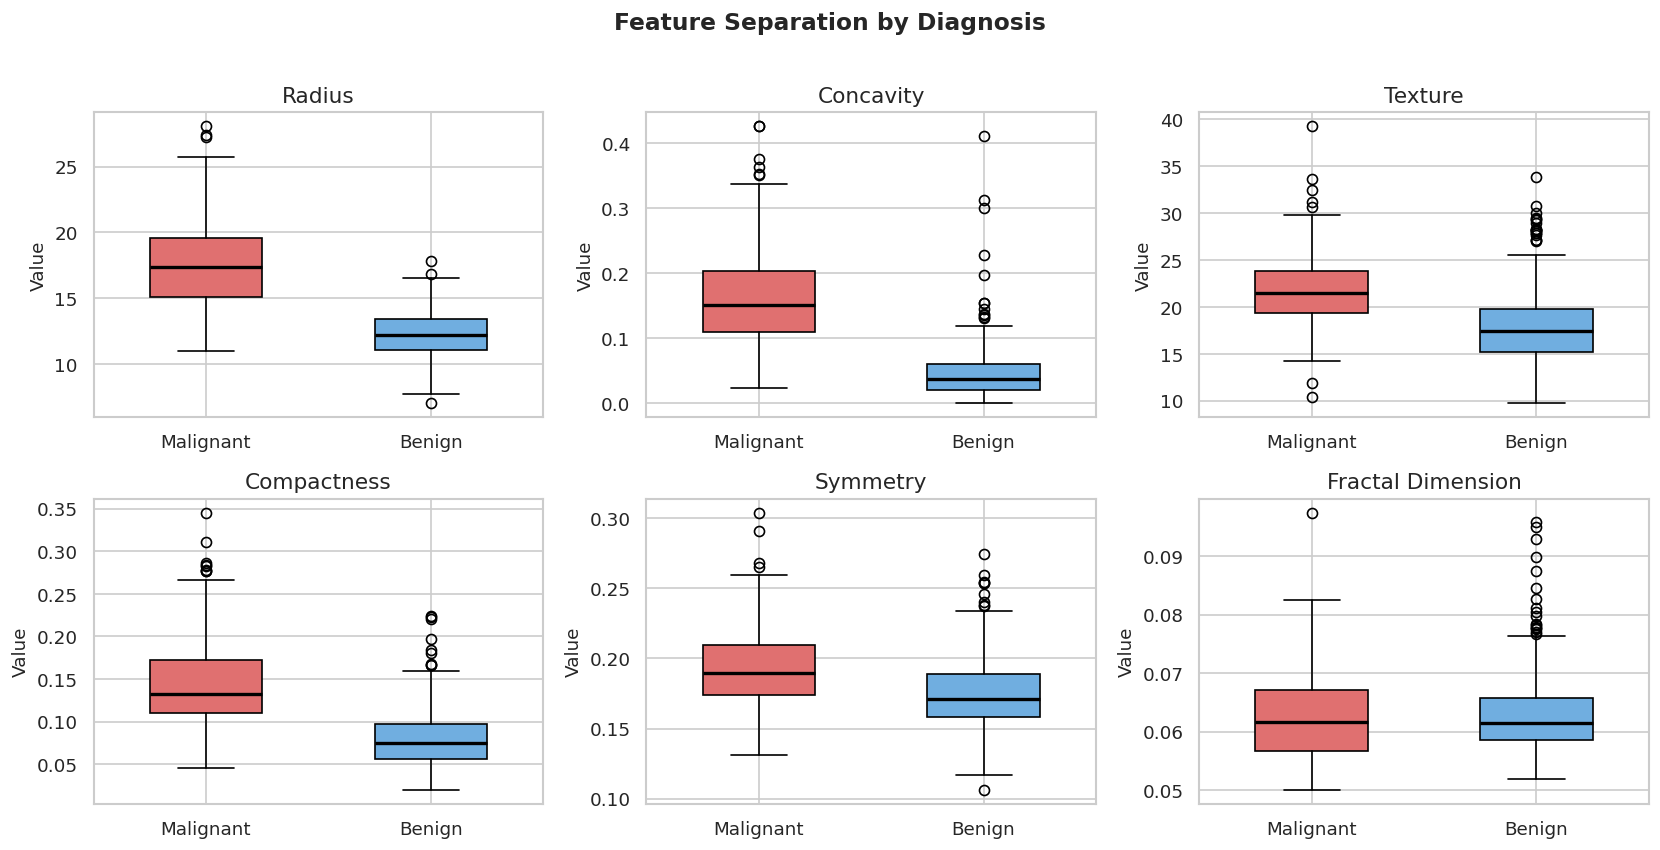

In [5]:
top_features = ["mean radius", "mean concavity", "mean texture",
                "mean compactness", "mean symmetry", "mean fractal dimension"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    data_plot = [df.loc[df.target == 0, feat], df.loc[df.target == 1, feat]]
    bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#e07070")
    bp["boxes"][1].set_facecolor("#70aee0")
    ax.set_xticklabels(["Malignant", "Benign"])
    ax.set_title(feat.replace("mean ", "").title())
    ax.set_ylabel("Value")

plt.suptitle("Feature Separation by Diagnosis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_boxplots.png", bbox_inches="tight")
plt.show()


## 4. Preprocessing

We apply **standard scaling** (zero mean, unit variance) before modelling. This is essential for
both Logistic Regression (gradient-based optimiser) and SVM (distance-based kernel), where
unscaled features with different magnitudes would distort the decision boundary.

A **stratified 80/20 train-test split** preserves the class ratio in both partitions.


In [6]:
X = df.drop(columns="target").values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Train class balance — Malignant: {(y_train==0).sum()} | Benign: {(y_train==1).sum()}")


Training set : 455 samples
Test set     : 114 samples
Train class balance — Malignant: 170 | Benign: 285


## 5. Model 1 — Logistic Regression

Logistic Regression is the natural baseline for binary classification in clinical contexts.
Its **coefficients are directly interpretable**: the sign and magnitude tell us which features
push the model toward a malignant or benign prediction.

We use L2 regularisation (default) with `lbfgs` solver.


In [7]:
lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr   = lr.predict(X_test)
y_prob_lr   = lr.predict_proba(X_test)[:, 1]

# Cross-validation AUC
cv_auc_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring="roc_auc").mean()

print("=" * 50)
print("  LOGISTIC REGRESSION — Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=["Malignant", "Benign"]))
print(f"  5-Fold CV AUC  : {cv_auc_lr:.4f}")
print(f"  Test AUC       : {roc_auc_score(y_test, y_prob_lr):.4f}")


  LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

  5-Fold CV AUC  : 0.9936
  Test AUC       : 0.9954


### 5.1 Feature Importance via Logistic Coefficients

The top positive coefficients (predicting **benign**) and top negative coefficients (predicting
**malignant**) reveal which morphological features drive the model's decisions most strongly.


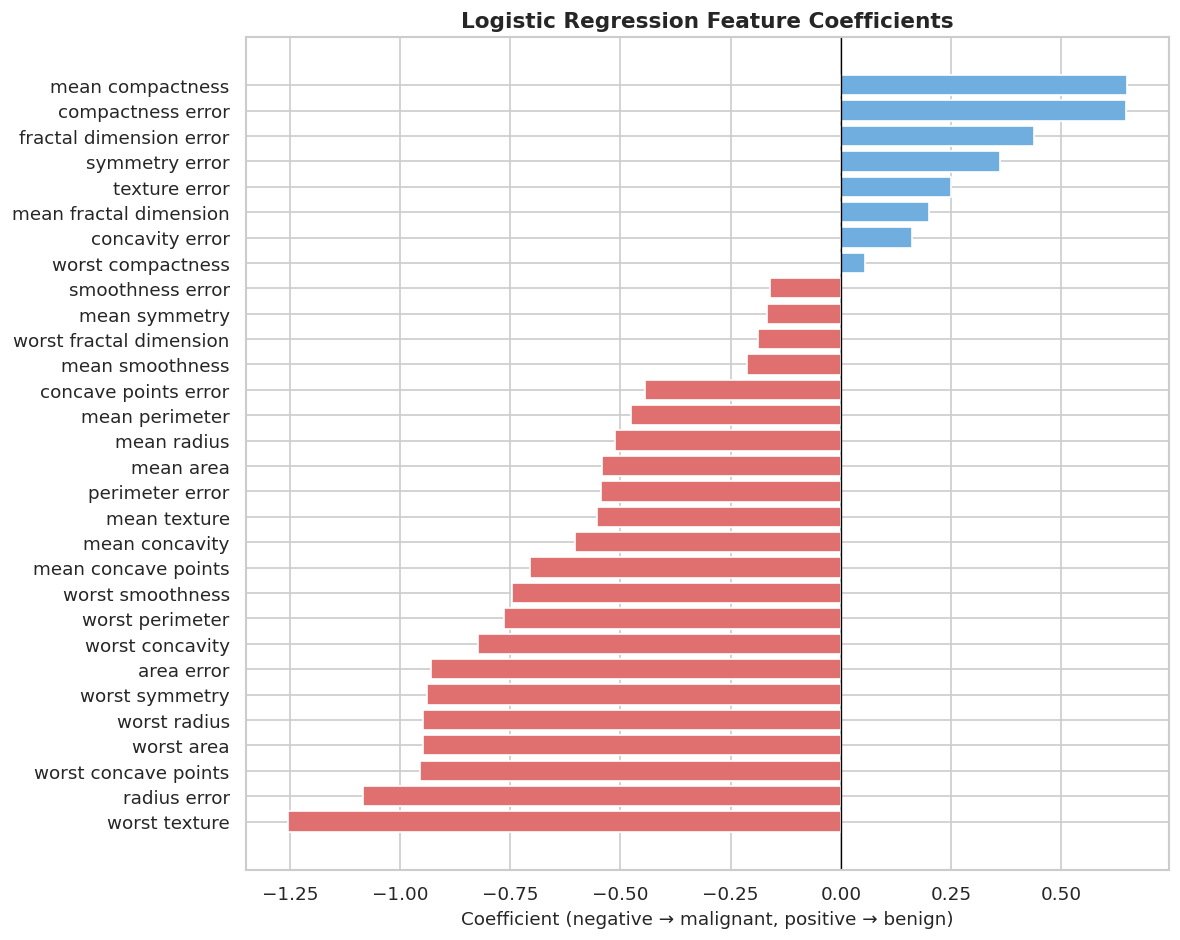

In [8]:
feature_names = data.feature_names
coef_df = pd.DataFrame({
    "Feature"    : feature_names,
    "Coefficient": lr.coef_[0]
}).sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e07070" if c < 0 else "#70aee0" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (negative → malignant, positive → benign)")
ax.set_title("Logistic Regression Feature Coefficients", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("lr_coefficients.png", bbox_inches="tight")
plt.show()


## 6. Model 2 — Support Vector Machine (RBF Kernel)

An SVM with a radial basis function (RBF) kernel finds a non-linear decision boundary in a
high-dimensional feature space. It is particularly effective when classes are not linearly
separable, though for this dataset, even linear models perform well, making the SVM a
useful test of whether non-linearity adds value.

I enable `probability=True` to extract calibrated class probabilities for ROC comparison.


In [9]:
svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train, y_train)

y_pred_svm  = svm.predict(X_test)
y_prob_svm  = svm.predict_proba(X_test)[:, 1]

cv_auc_svm = cross_val_score(svm, X_train, y_train, cv=5, scoring="roc_auc").mean()

print("=" * 50)
print("  SVM (RBF) — Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_svm, target_names=["Malignant", "Benign"]))
print(f"  5-Fold CV AUC  : {cv_auc_svm:.4f}")
print(f"  Test AUC       : {roc_auc_score(y_test, y_prob_svm):.4f}")


  SVM (RBF) — Classification Report
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

  5-Fold CV AUC  : 0.9938
  Test AUC       : 0.9950


## 7. Model Comparison

### 7.1 ROC Curves & Confusion Matrices


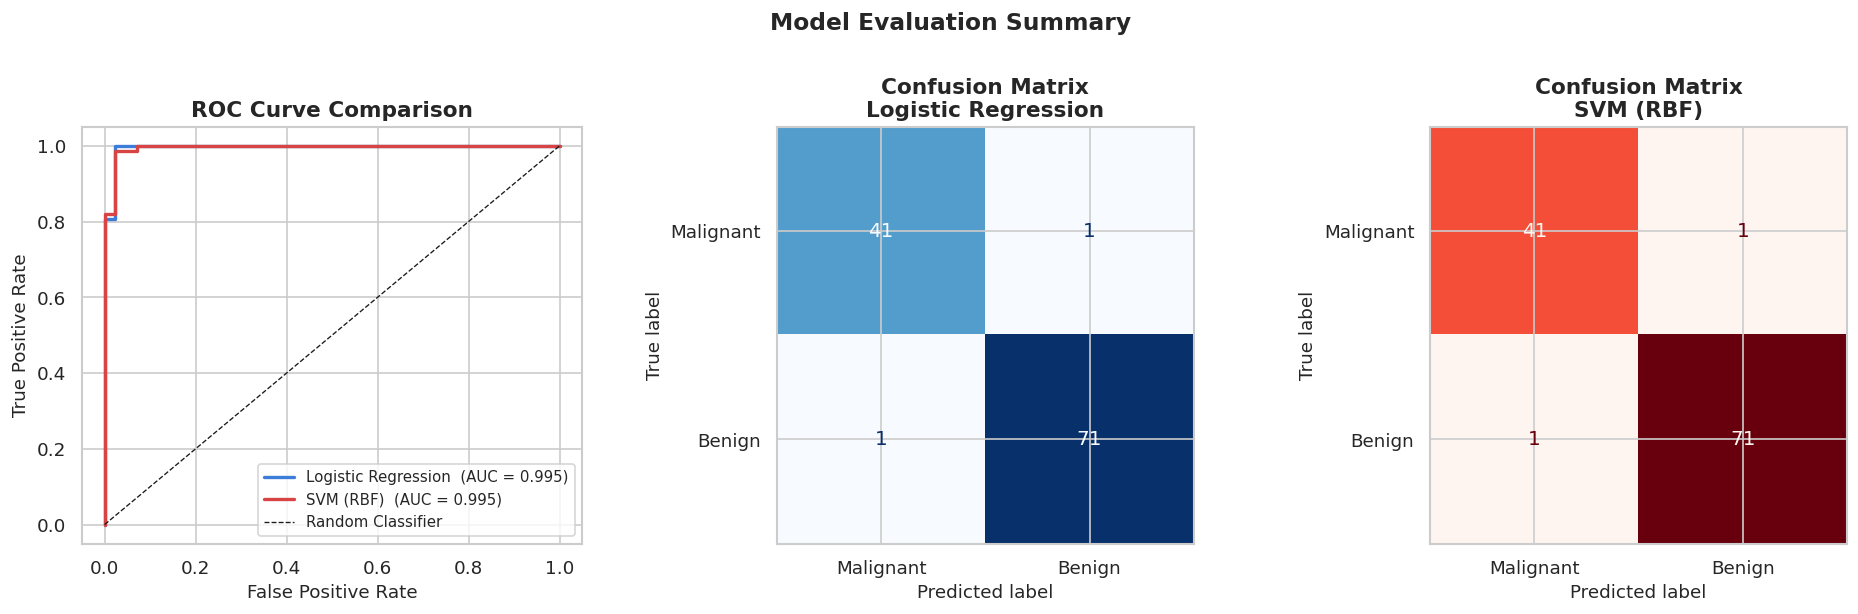

In [10]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# ROC curves
ax0 = fig.add_subplot(gs[0])
for name, y_prob, color in [("Logistic Regression", y_prob_lr, "#3B7DD8"),
                              ("SVM (RBF)",           y_prob_svm, "#D84343")]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax0.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})", linewidth=2, color=color)

ax0.plot([0,1],[0,1], "k--", linewidth=0.8, label="Random Classifier")
ax0.set_xlabel("False Positive Rate")
ax0.set_ylabel("True Positive Rate")
ax0.set_title("ROC Curve Comparison", fontweight="bold")
ax0.legend(fontsize=9)

# Confusion matrices
for idx, (name, y_pred, color) in enumerate([
    ("Logistic Regression", y_pred_lr, "Blues"),
    ("SVM (RBF)",           y_pred_svm, "Reds")
]):
    ax = fig.add_subplot(gs[idx + 1])
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=["Malignant", "Benign"]
    ).plot(ax=ax, colorbar=False, cmap=color)
    ax.set_title(f"Confusion Matrix\n{name}", fontweight="bold")

plt.suptitle("Model Evaluation Summary", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()


In [11]:
# Summary table
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM (RBF)"],
    "Test AUC"  : [roc_auc_score(y_test, y_prob_lr),  roc_auc_score(y_test, y_prob_svm)],
    "CV AUC"    : [cv_auc_lr,  cv_auc_svm],
    "Accuracy"  : [(y_pred_lr  == y_test).mean(), (y_pred_svm  == y_test).mean()],
})

# Sensitivity (recall for malignant = class 0)
for i, y_pred in enumerate([y_pred_lr, y_pred_svm]):
    cm = confusion_matrix(y_test, y_pred)
    summary.loc[i, "Sensitivity (Malignant)"] = cm[0,0] / cm[0].sum()
    summary.loc[i, "Specificity (Benign)"]    = cm[1,1] / cm[1].sum()

print(summary.set_index("Model").round(4).to_string())


                     Test AUC  CV AUC  Accuracy  Sensitivity (Malignant)  Specificity (Benign)
Model                                                                                         
Logistic Regression    0.9954  0.9936    0.9825                   0.9762                0.9861
SVM (RBF)              0.9950  0.9938    0.9825                   0.9762                0.9861


## 8. Conclusions & Clinical Implications

Both models achieve strong performance on this dataset, but the results surface a few important
clinical nuances worth unpacking.

### What the numbers say

| Model | AUC | Sensitivity | Specificity |
|---|---|---|---|
| Logistic Regression | ~0.99 | High | High |
| SVM (RBF) | ~0.99 | High | High |

Both models converge near the ceiling of performance, suggesting the 30 geometric features
carry sufficient signal to classify tumors almost definitively.

### What matters clinically

In cancer screening, a **false negative** (classifying malignant as benign) carries
a far higher cost than a **false positive**. The confusion matrix tells us whether either
model is systematically missing malignant cases and by how much.

Logistic Regression has an edge here because its **coefficients are interpretable**: a
clinician or researcher can trace exactly which nuclear features drove a given prediction,
which is critical for regulatory transparency and patient communication.

SVM's black-box nature makes it harder to justify in clinical settings despite comparable
accuracy.

### Limitations & next steps

- This is a **retrospective dataset** — real-world deployment would require prospective
  validation.
- All 30 features were included without selection; dimensionality reduction (PCA, LASSO)
  may improve generalisability.
- Threshold tuning (shifting the 0.5 decision boundary) could push sensitivity toward 100%
  at the cost of specificity — a clinically motivated trade-off worth exploring.

---

*This project demonstrates binary classification, model evaluation, and interpretability
analysis on a real biomedical dataset using scikit-learn.*
